<a href="https://colab.research.google.com/github/P-Baldinger/EcoSort---Artificial-Neural-Networks/blob/main/EcoSort_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EcoSort


## Step 0 — Imports

In [1]:
import os, shutil, random, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Using device: cpu


In [2]:
!pip install open_clip_torch
import open_clip
from PIL import Image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00


## Step 1 — Download the dataset

In [3]:
DATA_DIR = "/content/data"
ZIP_PATH = "/content/dataset-resized.zip"
RAW_URL = "https://github.com/garythung/trashnet/raw/refs/heads/master/data/dataset-resized.zip"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(ZIP_PATH):
    print("Downloading TrashNet...")
    urllib.request.urlretrieve(RAW_URL, ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(DATA_DIR)

# The zip unpacks to data/dataset-resized/<class>/*.jpg
RAW_DATA_DIR = os.path.join(DATA_DIR, "dataset-resized")

# The zip also contains junk like .DS_Store — keep only real class folders
classes = sorted([
    d for d in os.listdir(RAW_DATA_DIR)
    if os.path.isdir(os.path.join(RAW_DATA_DIR, d)) and not d.startswith(".")
])
print("Classes found:", classes)

def list_images(folder):
    """os.listdir, but skips hidden junk files like .DS_Store."""
    return [f for f in os.listdir(folder) if not f.startswith(".")]


Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Step 2 — Look at the data
Count images per class and eyeball a few samples.

{'cardboard': 403, 'glass': 501, 'metal': 410, 'paper': 594, 'plastic': 482, 'trash': 137}
Total images: 2527


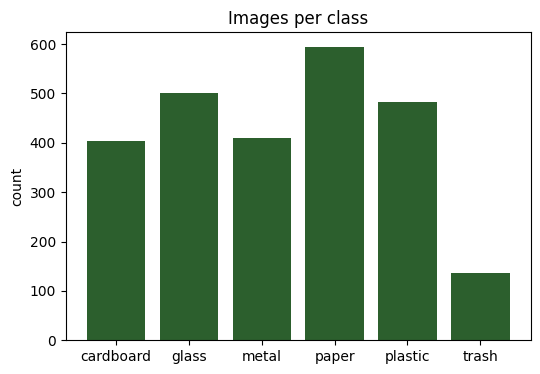

In [4]:
counts = {c: len(list_images(os.path.join(RAW_DATA_DIR, c))) for c in classes}
print(counts)
print("Total images:", sum(counts.values()))

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color="#2C5F2D")
plt.title("Images per class")
plt.ylabel("count")
plt.show()


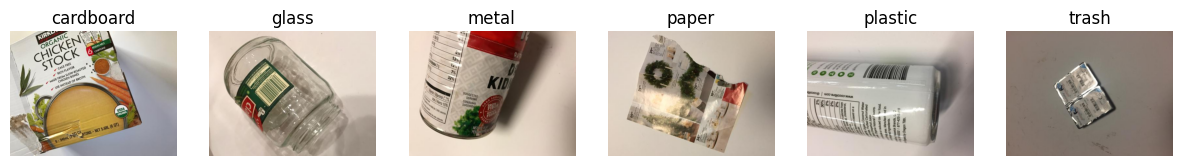

In [5]:
# A few sample images per class
fig, axes = plt.subplots(1, len(classes), figsize=(15, 3))
for ax, c in zip(axes, classes):
    sample_file = list_images(os.path.join(RAW_DATA_DIR, c))[0]
    img = Image.open(os.path.join(RAW_DATA_DIR, c, sample_file))
    ax.imshow(img)
    ax.set_title(c)
    ax.axis("off")
plt.show()


## Step 3 — Split into train / val / test

TrashNet doesn't ship an official split, so we make our own: **70% train / 15% val / 15% test**,
per class, so each split keeps the same class balance.

In [6]:
SPLIT_DIR = "/content/split"
SPLITS = {"train": 0.70, "val": 0.15, "test": 0.15}

if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in SPLITS:
    for c in classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, c), exist_ok=True)

for c in classes:
    files = list_images(os.path.join(RAW_DATA_DIR, c))
    random.shuffle(files)
    n = len(files)
    n_train = int(n * SPLITS["train"])
    n_val = int(n * SPLITS["val"])

    split_files = {
        "train": files[:n_train],
        "val": files[n_train:n_train + n_val],
        "test": files[n_train + n_val:],
    }
    for split, fnames in split_files.items():
        for f in fnames:
            shutil.copy(
                os.path.join(RAW_DATA_DIR, c, f),
                os.path.join(SPLIT_DIR, split, c, f),
            )

for split in SPLITS:
    total = sum(len(os.listdir(os.path.join(SPLIT_DIR, split, c))) for c in classes)
    print(f"{split}: {total} images")


train: 1766 images
val: 377 images
test: 384 images


## Step 4 — Material type *and* recyclable status

Rather than only ever saying "recyclable," the model should identify the actual material:
cardboard, glass, metal, paper, or plastic the same way the dataset's own folders are organized.
"Trash" is the only non-recyclable class.

So the model's real target is the **6-way material label**. Recyclable vs. non-recyclable is
just the overarching category we can always *derive* from that prediction afterward. It's a
grouping of the materials, not a separate thing the model needs to learn on its own.

In [7]:
RECYCLABLE_CLASSES = {"cardboard", "glass", "metal", "paper", "plastic"}
BINARY_CLASSES = ["non-recyclable", "recyclable"]  # index 0 / 1

def to_binary_label(material_class_name):
    """Maps a material class name to the overarching recyclable / non-recyclable category."""
    return 1 if material_class_name in RECYCLABLE_CLASSES else 0

def material_labels_to_binary(material_label_indices, material_classes):
    """Vectorized version: converts a list of material-class indices to binary labels."""
    return np.array([to_binary_label(material_classes[i]) for i in material_label_indices])


## Step 5 — Data loaders
Basic augmentation on train only; just resize + normalize for val/test.

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(SPLIT_DIR, "train"), transform=train_tf)
val_ds = datasets.ImageFolder(os.path.join(SPLIT_DIR, "val"), transform=eval_tf)
test_ds = datasets.ImageFolder(os.path.join(SPLIT_DIR, "test"), transform=eval_tf)

# ImageFolder assigns labels alphabetically, so this should match `classes` from Step 1
assert train_ds.classes == classes
print("Material classes (label order):", train_ds.classes)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")


Material classes (label order): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
train=1766  val=377  test=384


## Step 6 — Baselines: Random, Largest Class, and Logistic Regression

Before the neural network, three baselines: the same three from the proposal slide.
They now predict the **material type** directly (6 classes), same as the CNN will.
The first two are deliberately trivial "floor" baselines: if the CNN can't beat these,
something's wrong. Logistic Regression is the one real learned baseline, and uses the
same flattened-pixel trick as before.

**First, build the shared flattened-pixel features** that all three baselines will use.

In [9]:
def images_to_flat_array(root, size=32):
    """Loads every image in `root` (ImageFolder layout), resizes small, flattens to a vector.
    Returns material-class labels (0..5), matching `classes` order."""
    ds = datasets.ImageFolder(root, transform=transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor(),
    ]))
    assert ds.classes == classes

    X, y = [], []
    for image_tensor, material_idx in ds:
        X.append(image_tensor.numpy().flatten())
        y.append(material_idx)
    return np.array(X), np.array(y)

X_train, y_train = images_to_flat_array(os.path.join(SPLIT_DIR, "train"))
X_test, y_test = images_to_flat_array(os.path.join(SPLIT_DIR, "test"))
print(f"Feature matrix: {X_train.shape[0]} train / {X_test.shape[0]} test, {X_train.shape[1]} pixels each")


Feature matrix: 1766 train / 384 test, 3072 pixels each


### Baseline 1 — Random
Guesses a material class with equal probability, ignoring the data entirely.

In [10]:
random_clf = DummyClassifier(strategy="uniform", random_state=SEED)
random_clf.fit(X_train, y_train)
random_preds = random_clf.predict(X_test)

random_accuracy = accuracy_score(y_test, random_preds)
print(f"Random baseline test accuracy: {random_accuracy:.3f}")


Random baseline test accuracy: 0.164


### Baseline 2 — Largest Class
Always predicts whichever material class was most common in training.

In [11]:
largest_class_clf = DummyClassifier(strategy="most_frequent")
largest_class_clf.fit(X_train, y_train)
largest_class_preds = largest_class_clf.predict(X_test)

largest_class_accuracy = accuracy_score(y_test, largest_class_preds)
most_common_class = classes[largest_class_preds[0]]  # same prediction for every row
print(f"Largest Class baseline test accuracy: {largest_class_accuracy:.3f} (always predicts '{most_common_class}')")


Largest Class baseline test accuracy: 0.234 (always predicts 'paper')


### Baseline 3 — Logistic Regression
The one real learned baseline: a linear, multi-class classifier on flattened pixel vectors.

In [12]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)

logreg_accuracy = accuracy_score(y_test, logreg_preds)
print(f"Logistic Regression baseline test accuracy: {logreg_accuracy:.3f}")


Logistic Regression baseline test accuracy: 0.466


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 7 — The neural network (transfer learning)

We start from a ResNet-18 pretrained on ImageNet, freeze its convolutional layers, and
replace the final layer with a small classifier head for our 6 material classes.

In [13]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze the pretrained backbone — we'll only train the new final layer for now
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last residual block
for param in model.layer4.parameters():
    param.requires_grad = True

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes))  # one output per material class

# Keep the classifier trainable
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


## Step 8 — Train it

A simple training loop: for each epoch, run through the training batches, then check
accuracy on the validation set. Early stopping isn't automated here, just watch the
val accuracy and stop the cell early if it's already plateaued.

In [14]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

N_EPOCHS = 15  # small dataset + frozen backbone -> a handful of epochs is plenty to start

for epoch in range(N_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    train_loss = running_loss / len(train_ds)
    val_acc = evaluate(model, val_loader)
    print(f"Epoch {epoch+1}/{N_EPOCHS} — train loss: {train_loss:.3f} — val accuracy: {val_acc:.3f}")


Epoch 1/15 — train loss: 0.845 — val accuracy: 0.828
Epoch 2/15 — train loss: 0.378 — val accuracy: 0.846
Epoch 3/15 — train loss: 0.220 — val accuracy: 0.867
Epoch 4/15 — train loss: 0.172 — val accuracy: 0.878
Epoch 5/15 — train loss: 0.117 — val accuracy: 0.886
Epoch 6/15 — train loss: 0.076 — val accuracy: 0.886
Epoch 7/15 — train loss: 0.053 — val accuracy: 0.889
Epoch 8/15 — train loss: 0.051 — val accuracy: 0.897
Epoch 9/15 — train loss: 0.055 — val accuracy: 0.883
Epoch 10/15 — train loss: 0.036 — val accuracy: 0.878
Epoch 11/15 — train loss: 0.038 — val accuracy: 0.881
Epoch 12/15 — train loss: 0.027 — val accuracy: 0.889
Epoch 13/15 — train loss: 0.027 — val accuracy: 0.897
Epoch 14/15 — train loss: 0.020 — val accuracy: 0.894
Epoch 15/15 — train loss: 0.035 — val accuracy: 0.886


## Step 9 — Evaluate on the test set

Two views on the same predictions: how well the model identifies the **specific material**,
and how that translates into the **overarching recyclable / non-recyclable call**.

CNN material-level test accuracy: 0.896

              precision    recall  f1-score   support

   cardboard       1.00      0.95      0.97        61
       glass       0.94      0.76      0.84        76
       metal       0.83      0.95      0.89        62
       paper       0.97      0.94      0.96        90
     plastic       0.80      0.93      0.86        73
       trash       0.80      0.73      0.76        22

    accuracy                           0.90       384
   macro avg       0.89      0.88      0.88       384
weighted avg       0.90      0.90      0.90       384



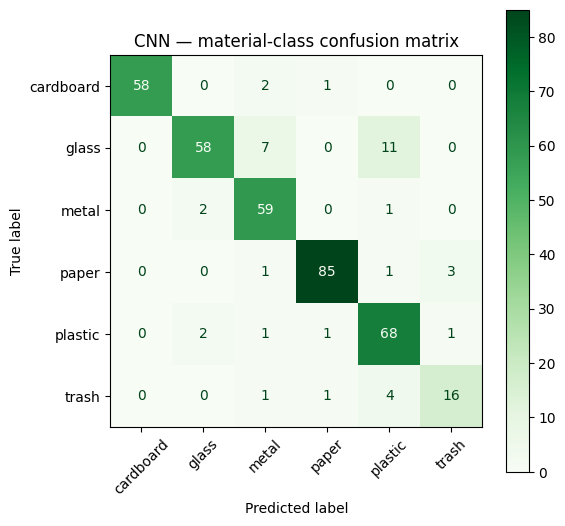

In [16]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cnn_accuracy = accuracy_score(all_labels, all_preds)
print(f"CNN material-level test accuracy: {cnn_accuracy:.3f}\n")
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Greens", ax=ax, xticks_rotation=45)
plt.title("CNN — material-class confusion matrix")
plt.show()


**Derived view:** collapse both predictions and ground truth down to recyclable / non-recyclable.

CNN derived recyclable/non-recyclable accuracy: 0.974

                precision    recall  f1-score   support

non-recyclable       0.80      0.73      0.76        22
    recyclable       0.98      0.99      0.99       362

      accuracy                           0.97       384
     macro avg       0.89      0.86      0.87       384
  weighted avg       0.97      0.97      0.97       384



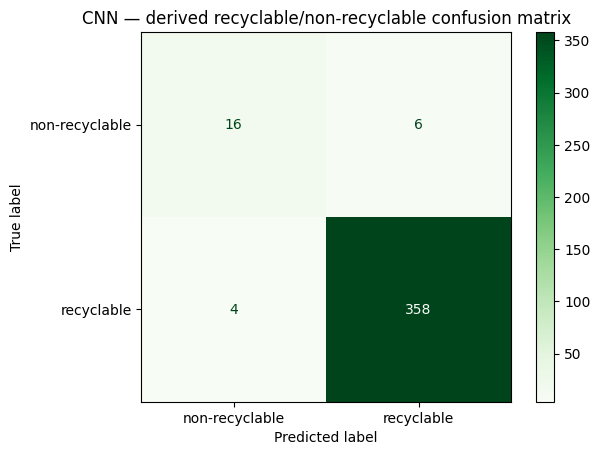

In [17]:
binary_preds = material_labels_to_binary(all_preds, classes)
binary_labels = material_labels_to_binary(all_labels, classes)

cnn_binary_accuracy = accuracy_score(binary_labels, binary_preds)
print(f"CNN derived recyclable/non-recyclable accuracy: {cnn_binary_accuracy:.3f}\n")
print(classification_report(binary_labels, binary_preds, target_names=BINARY_CLASSES))

cm_binary = confusion_matrix(binary_labels, binary_preds)
disp_binary = ConfusionMatrixDisplay(confusion_matrix=cm_binary, display_labels=BINARY_CLASSES)
disp_binary.plot(cmap="Greens")
plt.title("CNN — derived recyclable/non-recyclable confusion matrix")
plt.show()


## Step 9.5 — ResNet18 Error Analysis

Total misclassified images: 40
Error rate: 0.104


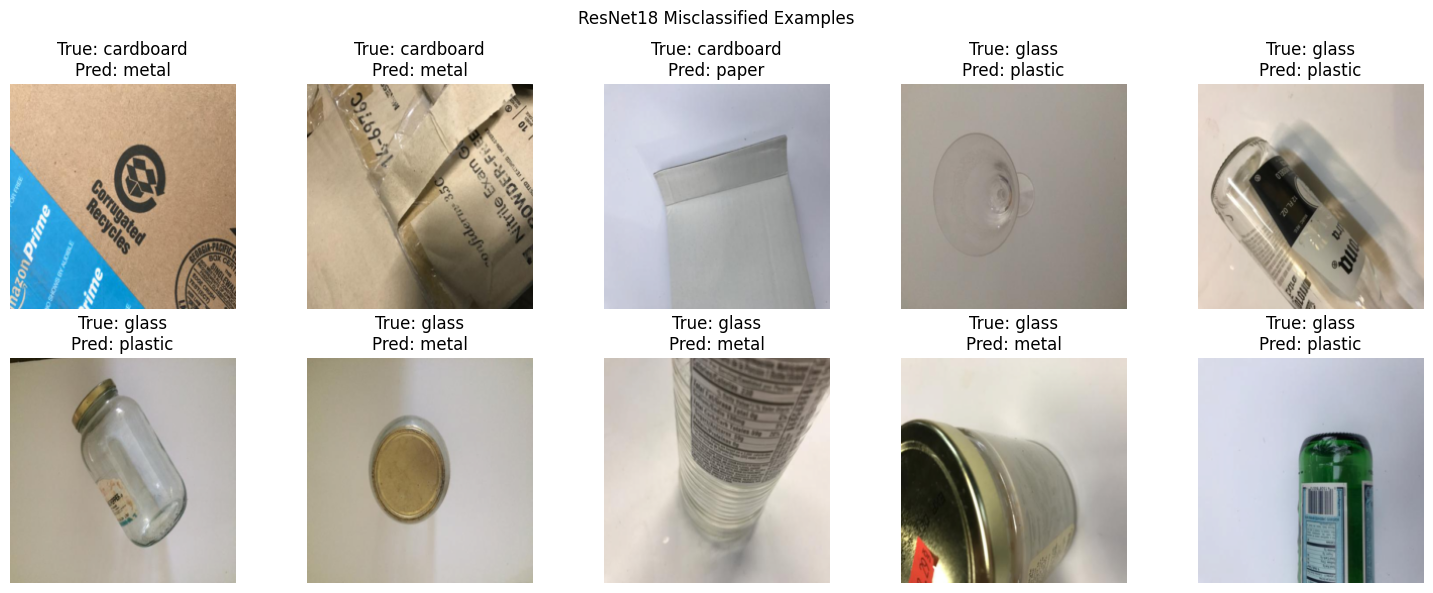

In [18]:
# Error Analysis: Visualize misclassified examples

wrong_indices = np.where(all_preds != all_labels)[0]

print(f"Total misclassified images: {len(wrong_indices)}")
print(f"Error rate: {len(wrong_indices)/len(all_labels):.3f}")


fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, idx in zip(axes.flatten(), wrong_indices[:10]):

    image, label = test_ds[idx]

    # Convert tensor back to image
    img = image.permute(1, 2, 0).numpy()

    # Undo normalization
    img = img * np.array([0.229, 0.224, 0.225])
    img = img + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    ax.imshow(img)

    ax.set_title(
        f"True: {classes[label]}\n"
        f"Pred: {classes[all_preds[idx]]}"
    )

    ax.axis("off")

plt.suptitle("ResNet18 Misclassified Examples")
plt.tight_layout()
plt.show()

In [19]:
from collections import Counter

errors = []

for true, pred in zip(all_labels, all_preds):
    if true != pred:
        errors.append(
            (classes[true], classes[pred])
        )

error_counts = Counter(errors)

print("Most common errors:")
for error, count in error_counts.most_common(10):
    print(f"{error[0]} → {error[1]} : {count}")

Most common errors:
glass → plastic : 11
glass → metal : 7
trash → plastic : 4
paper → trash : 3
cardboard → metal : 2
metal → glass : 2
plastic → glass : 2
cardboard → paper : 1
metal → plastic : 1
paper → plastic : 1


In [20]:
## Class Specific Accuracy

for i, material in enumerate(classes):

    idx = all_labels == i

    accuracy = accuracy_score(
        all_labels[idx],
        all_preds[idx]
    )

    print(
        f"{material}: {accuracy:.3f}"
    )

cardboard: 0.951
glass: 0.763
metal: 0.952
paper: 0.944
plastic: 0.932
trash: 0.727


## Step 10 — All baselines vs. the neural network

Model                 Material accuracy   Recyclable accuracy
--------------------------------------------------------------
Random                0.164               0.794
Largest Class         0.234               0.943
Logistic Regression   0.466               0.932
CNN (ResNet-18)       0.896               0.974


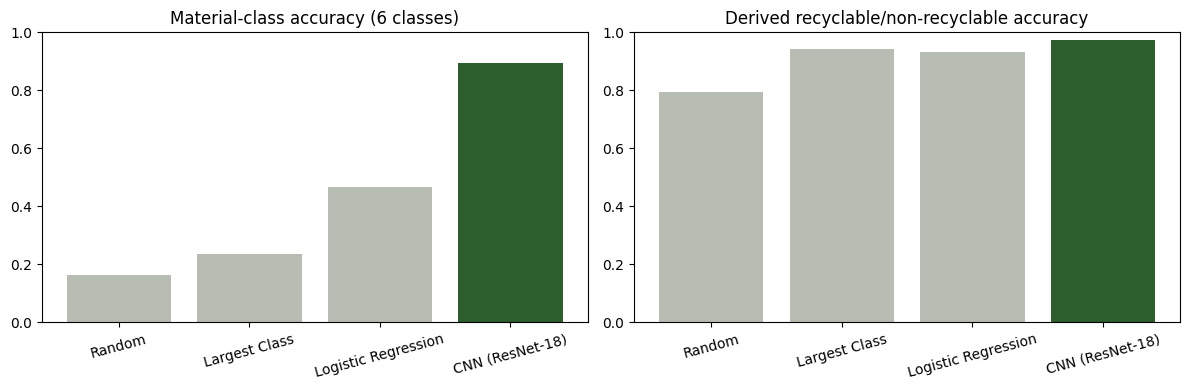

In [21]:
material_results = {
    "Random": random_accuracy,
    "Largest Class": largest_class_accuracy,
    "Logistic Regression": logreg_accuracy,
    "CNN (ResNet-18)": cnn_accuracy,
}

print(f"{'Model':<22}{'Material accuracy':<20}{'Recyclable accuracy'}")
print("-" * 62)

binary_results = {}
preds_by_model = {
    "Random": random_preds,
    "Largest Class": largest_class_preds,
    "Logistic Regression": logreg_preds,
}
for name, preds in preds_by_model.items():
    b_preds = material_labels_to_binary(preds, classes)
    b_labels = material_labels_to_binary(y_test, classes)
    binary_results[name] = accuracy_score(b_labels, b_preds)

binary_results["CNN (ResNet-18)"] = cnn_binary_accuracy

for name in material_results:
    print(f"{name:<22}{material_results[name]:<20.3f}{binary_results[name]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#B7BDB2", "#B7BDB2", "#B7BDB2", "#2C5F2D"]  # highlight the CNN

axes[0].bar(material_results.keys(), material_results.values(), color=colors)
axes[0].set_title("Material-class accuracy (6 classes)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(binary_results.keys(), binary_results.values(), color=colors)
axes[1].set_title("Derived recyclable/non-recyclable accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


##Step 11 - CLIP

In [22]:
## Load the CLIP model

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

clip_model = clip_model.to(device)
clip_model.eval()

tokenizer = open_clip.get_tokenizer("ViT-B-32")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [23]:
## Create your material prompts

clip_classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

prompts = [
    "a photo of cardboard",
    "a photo of glass",
    "a photo of metal",
    "a photo of paper",
    "a photo of plastic",
    "a photo of trash"
]

text_tokens = tokenizer(prompts).to(device)

with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

In [24]:
## Run CLIP on Test Images

clip_preds = []
clip_labels = []

test_raw = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test")
)

for path, label in test_raw.samples:

    image = Image.open(path).convert("RGB")

    image_input = clip_preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        image_features = clip_model.encode_image(image_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ text_features.T

        prediction = similarity.argmax(dim=1).item()

    clip_preds.append(prediction)
    clip_labels.append(label)

In [25]:
## Calculate CLIP Accuracy

clip_accuracy = accuracy_score(
    clip_labels,
    clip_preds
)

print(f"CLIP zero-shot accuracy: {clip_accuracy:.3f}")

CLIP zero-shot accuracy: 0.674


In [26]:
## Add to Comparison Table

material_results2 = {
    "Random": random_accuracy,
    "Largest Class": largest_class_accuracy,
    "Logistic Regression": logreg_accuracy,
    "CLIP Zero-shot": clip_accuracy,
    "CNN (ResNet-18)": cnn_accuracy,
}

import pandas as pd

results_df = pd.DataFrame(
    material_results2.items(),
    columns=["Model", "Accuracy"]
)

results_df

,Model,Accuracy
0,Random,0.164062
1,Largest Class,0.234375
2,Logistic Regression,0.466146
3,CLIP Zero-shot,0.674479
4,CNN (ResNet-18),0.895833


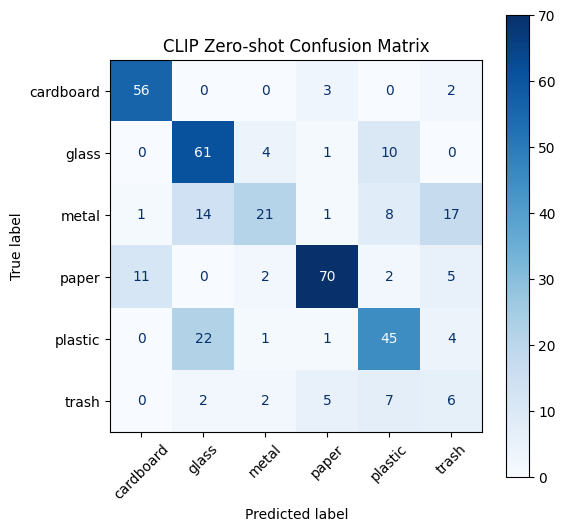

In [27]:
cm_clip = confusion_matrix(
    clip_labels,
    clip_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_clip,
    display_labels=clip_classes
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45
)

plt.title("CLIP Zero-shot Confusion Matrix")
plt.show()

In [28]:
clip_wrong = np.where(
    np.array(clip_preds) != np.array(clip_labels)
)[0]

print(
    f"CLIP misclassified images: {len(clip_wrong)}"
)

CLIP misclassified images: 125


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Model comparison
comparison_results = {
    "Random": random_accuracy,
    "Largest Class": largest_class_accuracy,
    "Logistic Regression": logreg_accuracy,
    "CLIP Zero-shot": clip_accuracy,
    "CNN (ResNet-18)": cnn_accuracy
}

# Create dataframe
comparison_df = pd.DataFrame(
    comparison_results.items(),
    columns=["Model", "Accuracy"]
)

# Add number of correct and incorrect predictions
comparison_df["Correct Images"] = (comparison_df["Accuracy"] * len(y_test)).round().astype(int)
comparison_df["Incorrect Images"] = len(y_test) - comparison_df["Correct Images"]

# Add error rate
comparison_df["Error Rate"] = 1 - comparison_df["Accuracy"]

comparison_df

,Model,Accuracy,Correct Images,Incorrect Images,Error Rate
0,Random,0.164062,63,321,0.835938
1,Largest Class,0.234375,90,294,0.765625
2,Logistic Regression,0.466146,179,205,0.533854
3,CLIP Zero-shot,0.674479,259,125,0.325521
4,CNN (ResNet-18),0.895833,344,40,0.104167


##Step 12 - ResNet Embedding

In [32]:
import torch
import torch.nn as nn
from torchvision import models

# Copy the trained model architecture
feature_extractor = models.resnet18(weights=None)

# Match your trained classifier
feature_extractor.fc = nn.Linear(
    feature_extractor.fc.in_features,
    len(classes)
)

# Copy trained weights from current model
feature_extractor.load_state_dict(model.state_dict())

# Remove classification layer
feature_extractor.fc = nn.Identity()

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("ResNet embedding model ready!")

ResNet embedding model ready!


In [46]:
## ResNet Embedding Classification Using Class Averages

embedding_preds = []
embedding_labels = []

# Extract training embeddings
X_train_embed, y_train_embed = extract_embeddings(
    train_loader,
    feature_extractor
)

# Calculate average embedding for each class
class_prototypes = {}

for i, material in enumerate(classes):
    class_prototypes[i] = X_train_embed[y_train_embed == i].mean(axis=0)

print("Created class average embeddings")

# Run ResNet embeddings on test images
test_raw = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test"),
    transform=eval_tf
)

with torch.no_grad():

    for image, label in test_raw:

        image_input = image.unsqueeze(0).to(device)

        # Get image embedding
        image_features = feature_extractor(image_input)

        image_features = image_features.cpu().numpy()

        # Normalize
        image_features = image_features / np.linalg.norm(
            image_features
        )

        # Compare with class averages
        similarities = image_features @ prototype_matrix.T

        prediction = similarities.argmax()

        embedding_preds.append(prediction)
        embedding_labels.append(label)


embedding_accuracy = accuracy_score(
    embedding_labels,
    embedding_preds
)

print(
    f"ResNet Embedding Prototype Accuracy: {embedding_accuracy:.3f}"
)

Created class average embeddings
ResNet Embedding Prototype Accuracy: 0.893


In [47]:
import pandas as pd

comparison_results = {
    "Random": random_accuracy,
    "Largest Class": largest_class_accuracy,
    "Logistic Regression": logreg_accuracy,
    "ResNet-18 Embedding": embedding_accuracy,
    "CLIP Zero-shot": clip_accuracy,
    "CNN (ResNet-18 Fine-tuned)": cnn_accuracy
}

comparison_df = pd.DataFrame(
    comparison_results.items(),
    columns=["Model", "Accuracy"]
)

comparison_df["Correct Images"] = (
    comparison_df["Accuracy"] * len(y_test)
).round().astype(int)

comparison_df["Incorrect Images"] = (
    len(y_test) - comparison_df["Correct Images"]
)

comparison_df["Error Rate"] = 1 - comparison_df["Accuracy"]

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Correct Images,Incorrect Images,Error Rate
0,CNN (ResNet-18 Fine-tuned),0.895833,344,40,0.104167
1,ResNet-18 Embedding,0.893229,343,41,0.106771
2,CLIP Zero-shot,0.674479,259,125,0.325521
3,Logistic Regression,0.466146,179,205,0.533854
4,Largest Class,0.234375,90,294,0.765625
5,Random,0.164062,63,321,0.835938


In [59]:
from collections import Counter
import numpy as np

# Find misclassified ResNet embedding examples
embedding_errors = []

for true, pred in zip(embedding_labels, embedding_preds):
    if true != pred:
        embedding_errors.append(
            (classes[true], classes[pred])
        )

error_counts_embedding = Counter(embedding_errors)

print("Most common ResNet embedding errors:")

for error, count in error_counts_embedding.most_common(3):
    print(f"{error[0]} → {error[1]} : {count}")

Most common ResNet embedding errors:
glass → plastic : 9
glass → metal : 9
paper → trash : 4


In [62]:
from collections import Counter
import numpy as np

# Find misclassified CLIP examples
clip_errors = []

for true, pred in zip(clip_labels, clip_preds):
    if true != pred:
        clip_errors.append(
            (classes[true], classes[pred])
        )

error_counts_clip = Counter(clip_errors)

print("Most common CLIP errors:")

for error, count in error_counts_clip.most_common(3):
    print(f"{error[0]} → {error[1]} : {count}")

Most common CLIP errors:
plastic → glass : 22
metal → trash : 17
metal → glass : 14


Total misclassified images: 41


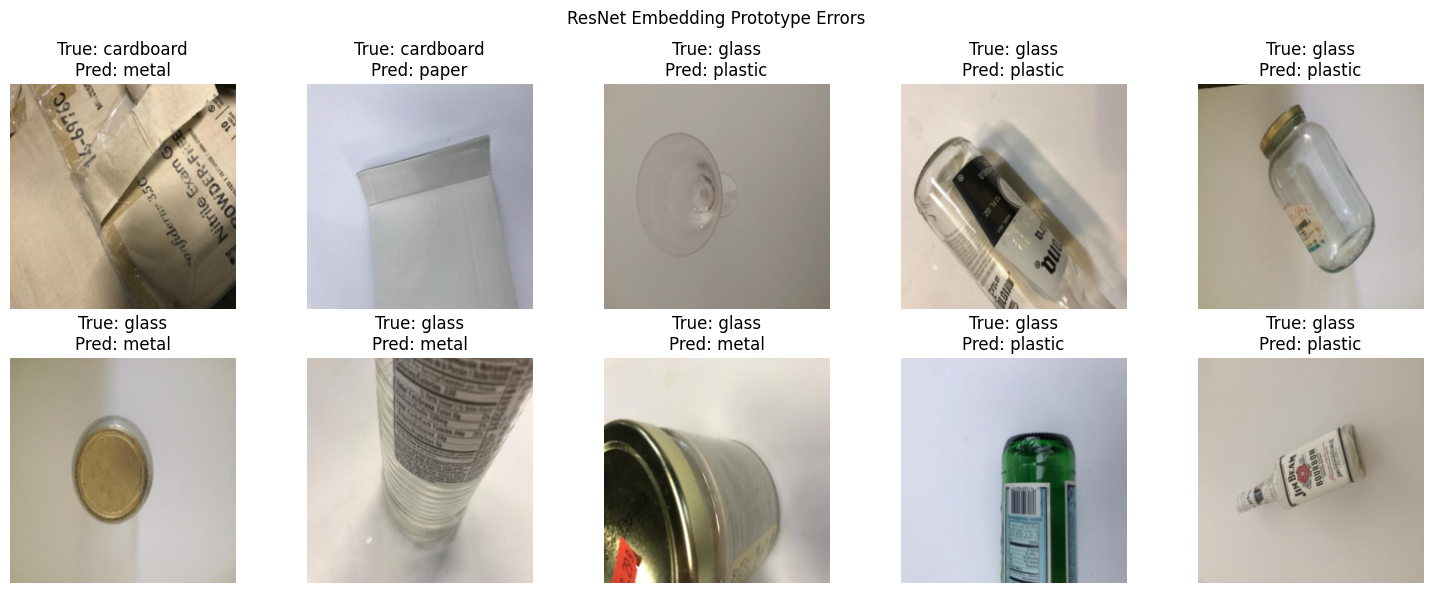

In [49]:
wrong_indices = np.where(
    np.array(embedding_preds) != np.array(embedding_labels)
)[0]

print(f"Total misclassified images: {len(wrong_indices)}")


fig, axes = plt.subplots(2, 5, figsize=(15, 6))

test_raw = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test"),
    transform=eval_tf
)

for ax, idx in zip(axes.flatten(), wrong_indices[:10]):

    image, label = test_raw[idx]

    img = image.permute(1,2,0).numpy()

    img = img * np.array([0.229,0.224,0.225])
    img = img + np.array([0.485,0.456,0.406])
    img = np.clip(img,0,1)

    ax.imshow(img)

    ax.set_title(
        f"True: {classes[label]}\n"
        f"Pred: {classes[embedding_preds[idx]]}"
    )

    ax.axis("off")

plt.suptitle("ResNet Embedding Prototype Errors")
plt.tight_layout()
plt.show()

Total CLIP misclassified images: 125


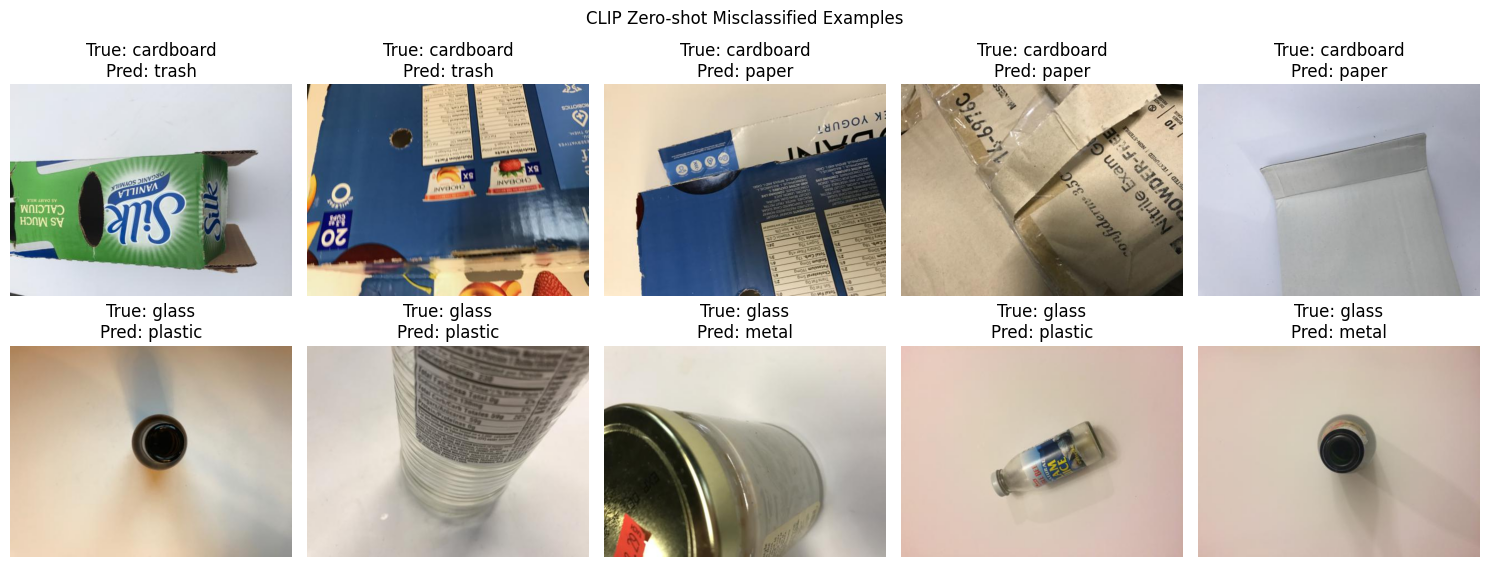

In [63]:
wrong_indices = np.where(
    np.array(clip_preds) != np.array(clip_labels)
)[0]

print(f"Total CLIP misclassified images: {len(wrong_indices)}")

test_raw = datasets.ImageFolder(
    os.path.join(SPLIT_DIR, "test")
)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, idx in zip(axes.flatten(), wrong_indices[:10]):

    path, label = test_raw.samples[idx]

    img = Image.open(path).convert("RGB")

    ax.imshow(img)

    ax.set_title(
        f"True: {classes[label]}\n"
        f"Pred: {classes[clip_preds[idx]]}"
    )

    ax.axis("off")

plt.suptitle("CLIP Zero-shot Misclassified Examples")
plt.tight_layout()
plt.show()